In [1]:
!pip3 install pyspark


In [3]:
import pyspark
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("Week1_CN7030") \
                            .master("local[*]")\
                            .config("spark.some.config.option", "some-value") \
                            .getOrCreate()

In [7]:
myfile="/content/Airline_Delay_Cause.csv"
df = spark.read.format("csv").load(myfile, inferSchema=True, header=True)


In [8]:
df.show(5)

+----+-----+-------+-------------+-------+--------------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|year|month|carrier| carrier_name|airport|        airport_name|arr_flights|arr_del15|carrier_ct|weather_ct|nas_ct|security_ct|late_aircraft_ct|arr_cancelled|arr_diverted|arr_delay|carrier_delay|weather_delay|nas_delay|security_delay|late_aircraft_delay|
+----+-----+-------+-------------+-------+--------------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|2025|    1|     G4|Allegiant Air|    ELM|Elmira/Corning, N...|         30|        0|       0.0|       0.0|   0.0|        0.0|             0.0|            0|           0|        0|            0|            0|        0|             0|     

In [9]:
df.printSchema()

root
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- carrier: string (nullable = true)
 |-- carrier_name: string (nullable = true)
 |-- airport: string (nullable = true)
 |-- airport_name: string (nullable = true)
 |-- arr_flights: integer (nullable = true)
 |-- arr_del15: integer (nullable = true)
 |-- carrier_ct: double (nullable = true)
 |-- weather_ct: double (nullable = true)
 |-- nas_ct: double (nullable = true)
 |-- security_ct: double (nullable = true)
 |-- late_aircraft_ct: double (nullable = true)
 |-- arr_cancelled: integer (nullable = true)
 |-- arr_diverted: integer (nullable = true)
 |-- arr_delay: integer (nullable = true)
 |-- carrier_delay: integer (nullable = true)
 |-- weather_delay: integer (nullable = true)
 |-- nas_delay: integer (nullable = true)
 |-- security_delay: integer (nullable = true)
 |-- late_aircraft_delay: integer (nullable = true)



In [10]:
print(df.count())
print(len(df.columns))


398233
21


In [11]:
# Count rows using rdd attribute
row_count = df.rdd.count()

print(f'The DataFrame has {row_count} rows.')

The DataFrame has 398233 rows.


In [12]:
# Change the number of partitions
df = df.repartition(4)
df.rdd.getNumPartitions()

4

In [13]:
from pyspark.sql.functions import col, sum

df.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
]).show()

+----+-----+-------+------------+-------+------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|year|month|carrier|carrier_name|airport|airport_name|arr_flights|arr_del15|carrier_ct|weather_ct|nas_ct|security_ct|late_aircraft_ct|arr_cancelled|arr_diverted|arr_delay|carrier_delay|weather_delay|nas_delay|security_delay|late_aircraft_delay|
+----+-----+-------+------------+-------+------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|   0|    0|      0|           0|      0|           0|        657|      950|       657|       657|   657|        657|             657|          657|         657|      657|          657|          657|      657|           657|                657|
+----+-----+-------+

In [18]:
numeric_cols = [
    "arr_flights","arr_del15","carrier_ct","weather_ct",
    "nas_ct","security_ct","late_aircraft_ct",
    "arr_cancelled","arr_diverted"
]

df = df.fillna(0, subset=numeric_cols)

In [19]:
df = df.filter(col("arr_flights") > 0)

In [21]:
from pyspark.sql.functions import *
import matplotlib.pyplot as plt
import pandas as pd

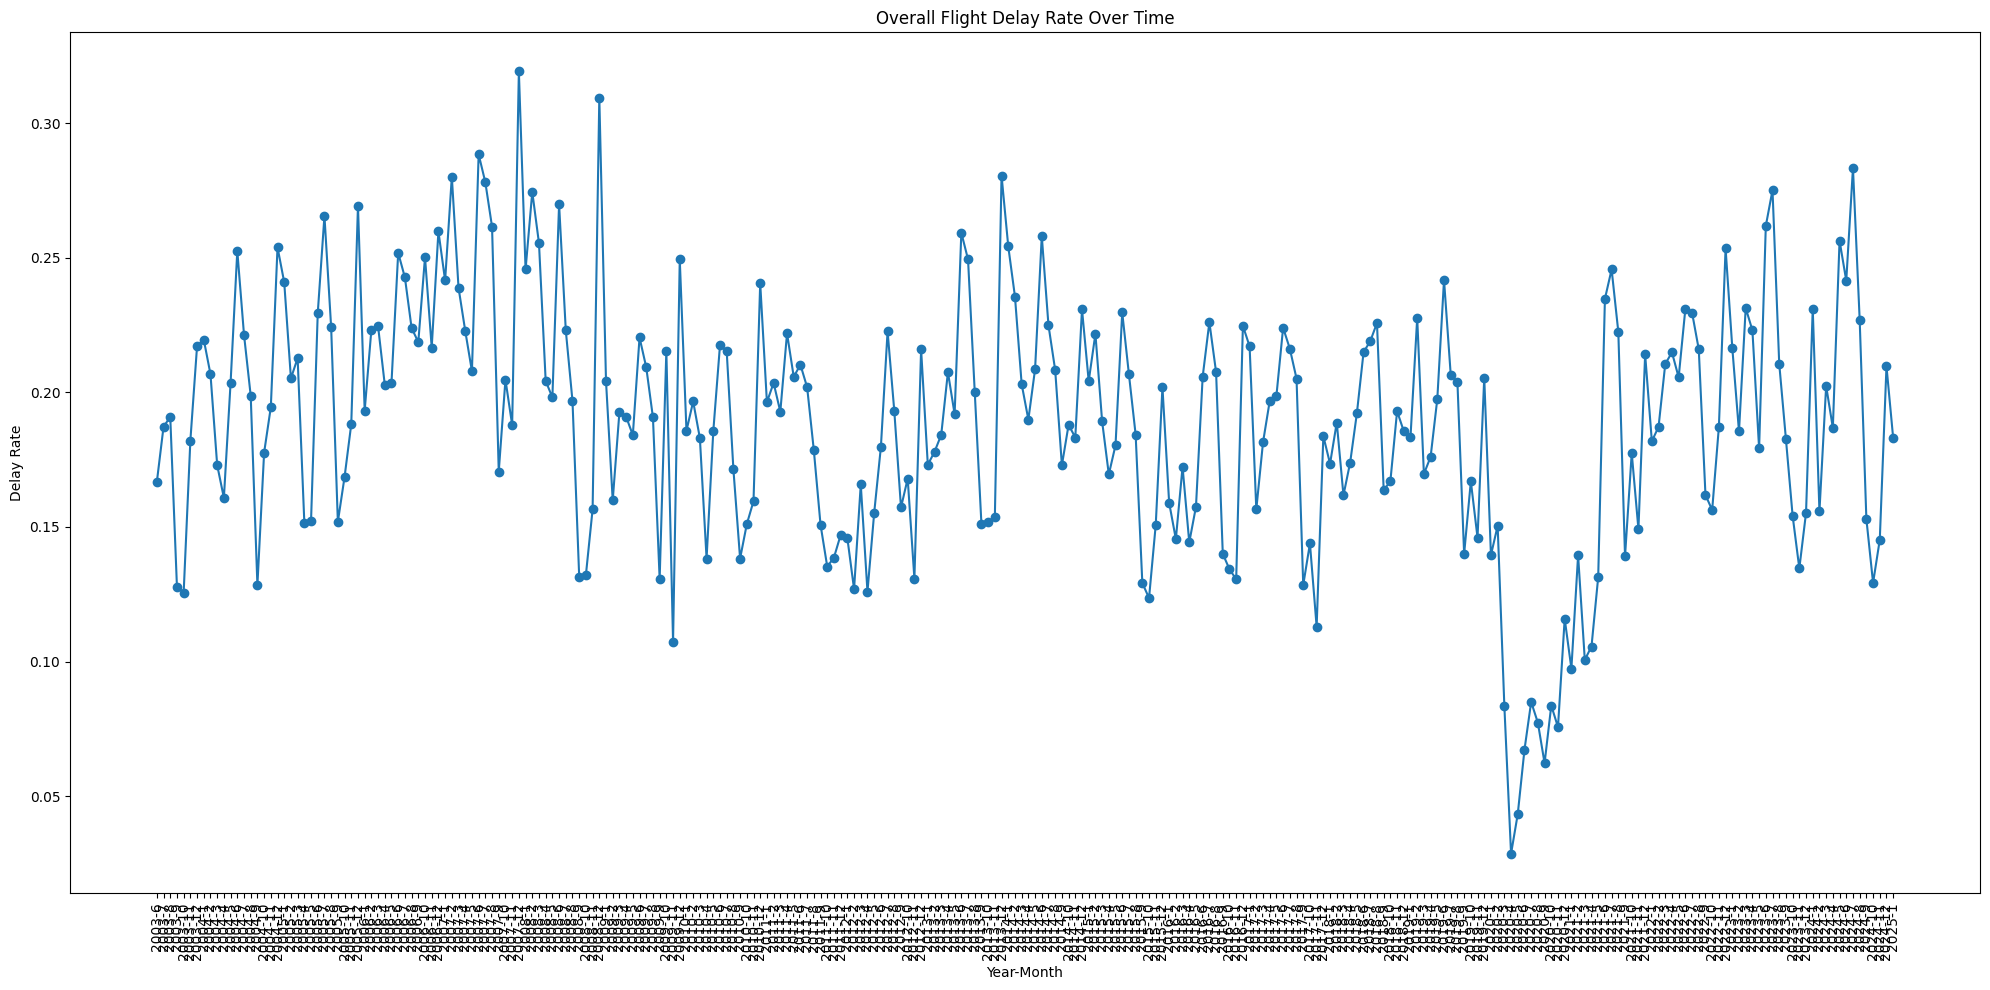

In [23]:
delay_trend = (
    df.groupBy("year","month")
      .agg(
          (sum("arr_del15")/sum("arr_flights")).alias("delay_rate")
      )
      .orderBy("year","month")
)

delay_pd = delay_trend.toPandas()

delay_pd["Date"] = (
    delay_pd["year"].astype(str) + "-" +
    delay_pd["month"].astype(str)
)

plt.figure(figsize=(20,10))
plt.plot(delay_pd["Date"], delay_pd["delay_rate"], marker="o")
plt.xticks(rotation=90)
plt.title("Overall Flight Delay Rate Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Delay Rate")
plt.tight_layout()
plt.show()

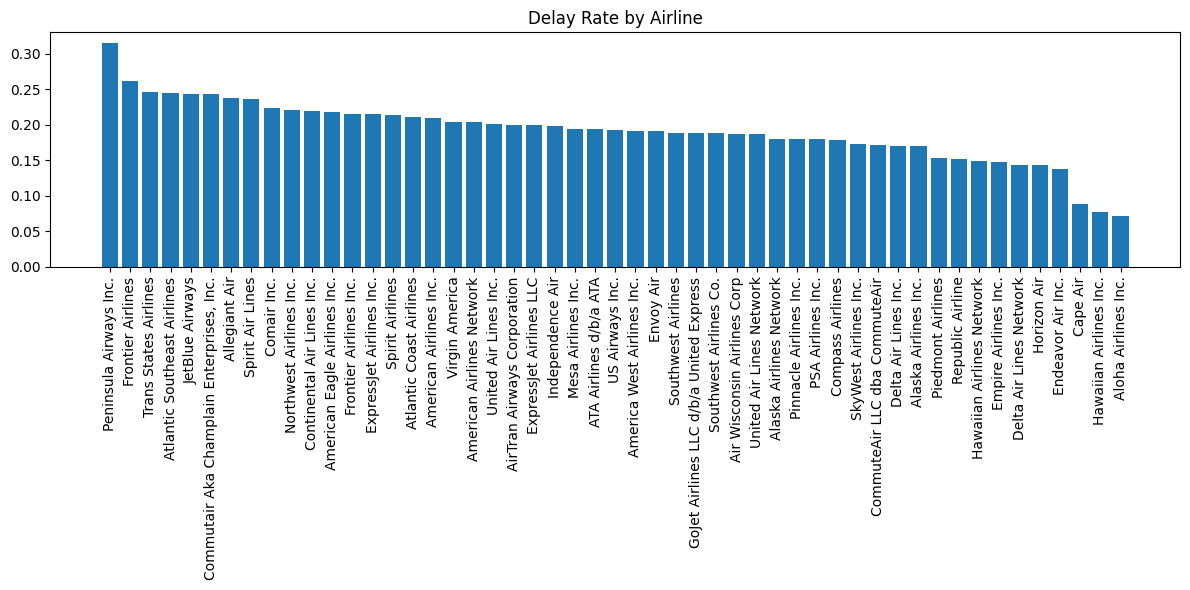

In [24]:
carrier_delay = (
    df.groupBy("carrier_name")
      .agg(
          (sum("arr_del15")/sum("arr_flights")).alias("delay_rate")
      )
      .orderBy(desc("delay_rate"))
)

carrier_pd = carrier_delay.toPandas()

plt.figure(figsize=(12,6))
plt.bar(carrier_pd["carrier_name"], carrier_pd["delay_rate"])
plt.xticks(rotation=90)
plt.title("Delay Rate by Airline")
plt.tight_layout()
plt.show()

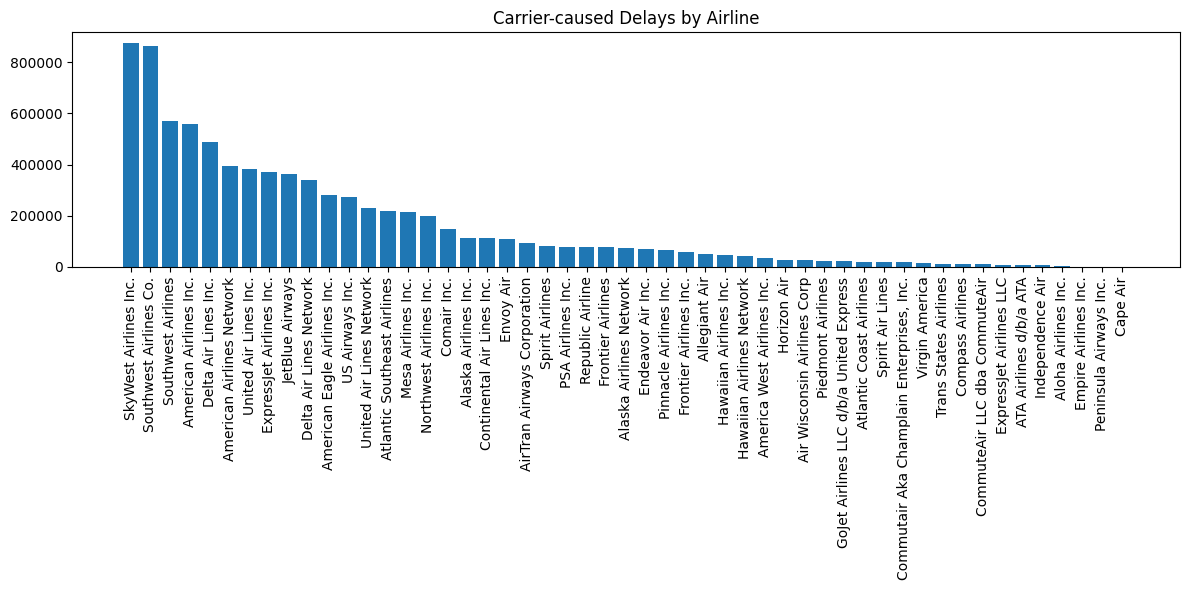

In [25]:
carrier_ct = (
    df.groupBy("carrier_name")
      .agg(sum("carrier_ct").alias("carrier_delays"))
      .orderBy(desc("carrier_delays"))
)

carrier_ct_pd = carrier_ct.toPandas()

plt.figure(figsize=(12,6))
plt.bar(
    carrier_ct_pd["carrier_name"],
    carrier_ct_pd["carrier_delays"]
)

plt.xticks(rotation=90)
plt.title("Carrier-caused Delays by Airline")
plt.tight_layout()
plt.show()

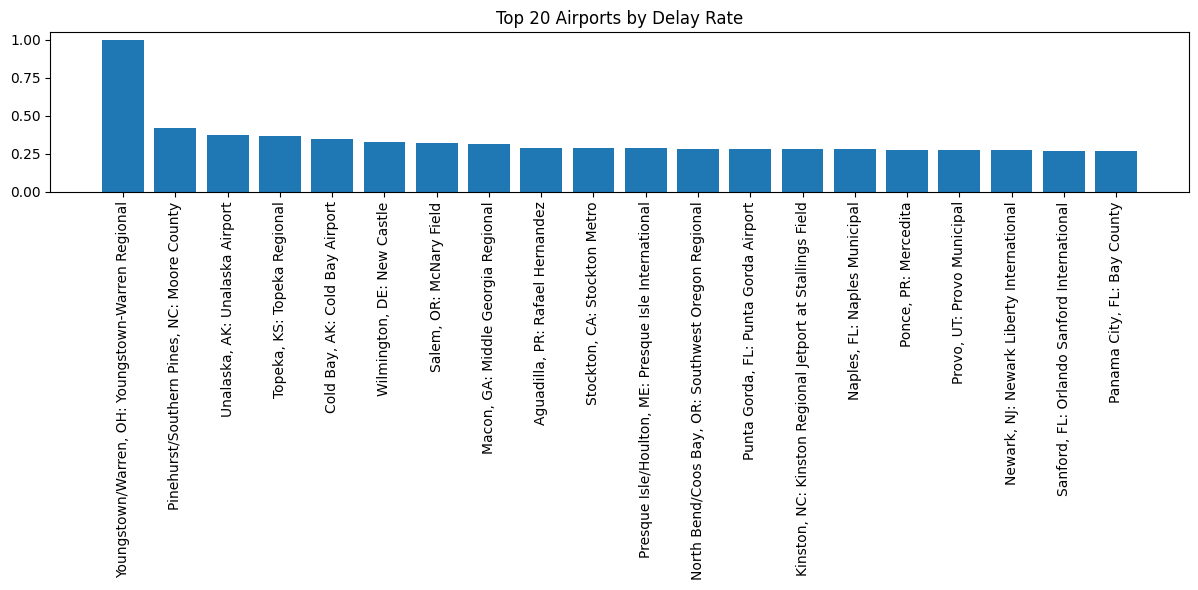

In [26]:
airport_delay = (
    df.groupBy("airport_name")
      .agg(
          (sum("arr_del15")/sum("arr_flights")).alias("delay_rate")
      )
      .orderBy(desc("delay_rate"))
)

airport_pd = airport_delay.limit(20).toPandas()

plt.figure(figsize=(12,6))
plt.bar(
    airport_pd["airport_name"],
    airport_pd["delay_rate"]
)

plt.xticks(rotation=90)
plt.title("Top 20 Airports by Delay Rate")
plt.tight_layout()
plt.show()

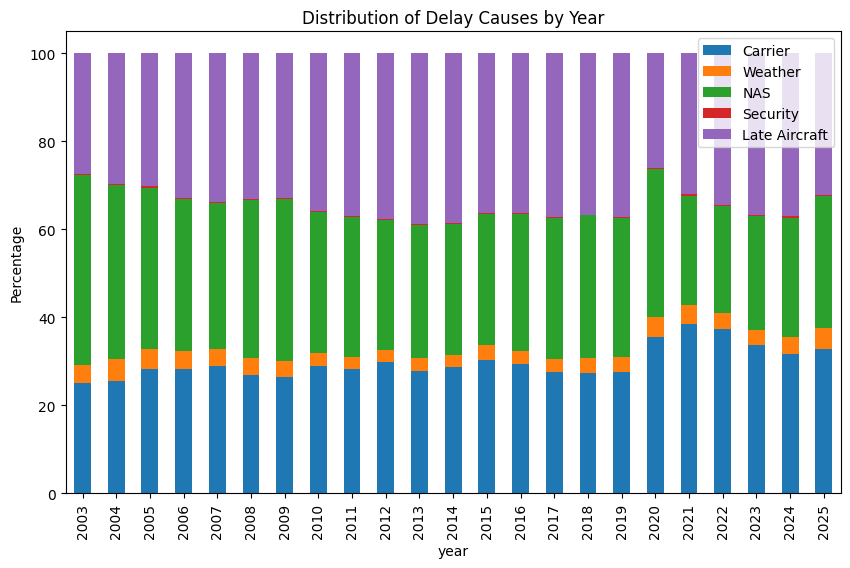

In [27]:
cause_year = (
    df.groupBy("year")
      .agg(
          sum("carrier_ct").alias("Carrier"),
          sum("weather_ct").alias("Weather"),
          sum("nas_ct").alias("NAS"),
          sum("security_ct").alias("Security"),
          sum("late_aircraft_ct").alias("Late Aircraft")
      )
      .orderBy("year")
)

cause_pd = cause_year.toPandas()
cause_pd = cause_pd.set_index("year")

cause_pct = cause_pd.div(cause_pd.sum(axis=1), axis=0) * 100

cause_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.ylabel("Percentage")
plt.title("Distribution of Delay Causes by Year")
plt.show()

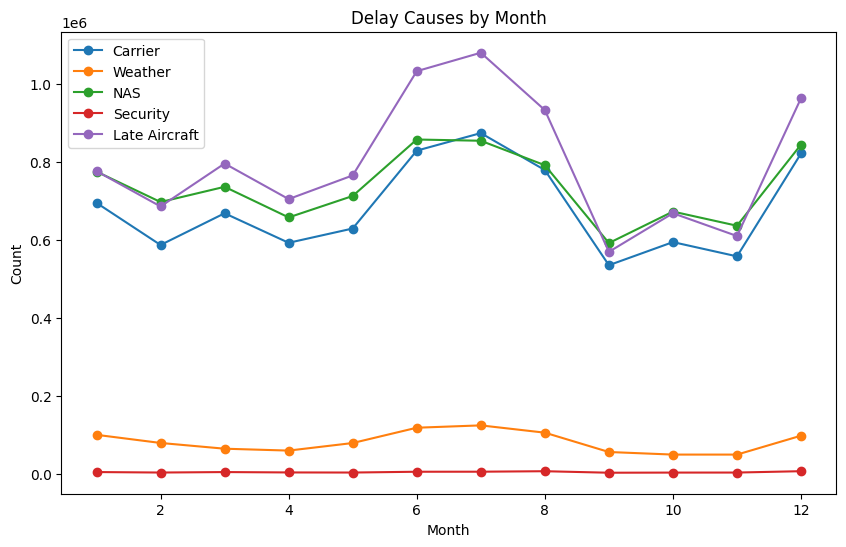

In [28]:
season = (
    df.groupBy("month")
      .agg(
          sum("carrier_ct").alias("Carrier"),
          sum("weather_ct").alias("Weather"),
          sum("nas_ct").alias("NAS"),
          sum("security_ct").alias("Security"),
          sum("late_aircraft_ct").alias("Late Aircraft")
      )
      .orderBy("month")
)

season_pd = season.toPandas()

plt.figure(figsize=(10,6))

for c in [
    "Carrier",
    "Weather",
    "NAS",
    "Security",
    "Late Aircraft"
]:
    plt.plot(
        season_pd["month"],
        season_pd[c],
        marker="o",
        label=c
    )

plt.legend()
plt.xlabel("Month")
plt.ylabel("Count")
plt.title("Delay Causes by Month")
plt.show()

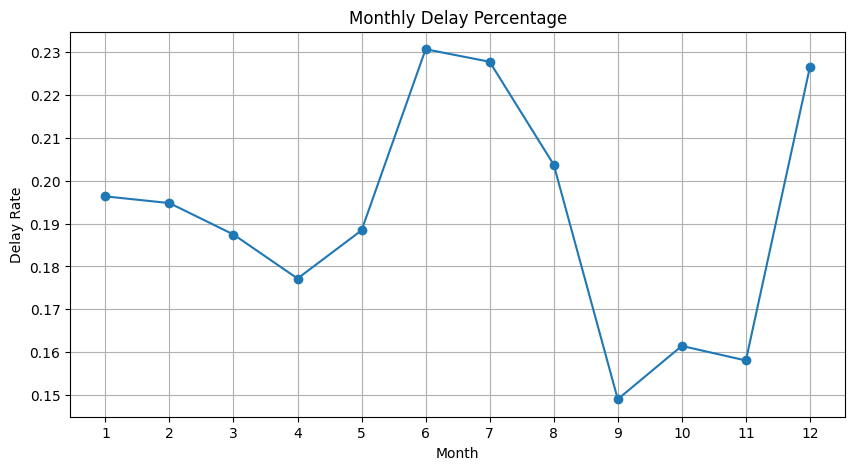

In [29]:
month_delay = (
    df.groupBy("month")
      .agg(
          (sum("arr_del15")/sum("arr_flights")).alias("delay_rate")
      )
      .orderBy("month")
)

month_pd = month_delay.toPandas()

plt.figure(figsize=(10,5))
plt.plot(
    month_pd["month"],
    month_pd["delay_rate"],
    marker="o"
)

plt.xticks(range(1,13))
plt.xlabel("Month")
plt.ylabel("Delay Rate")
plt.title("Monthly Delay Percentage")
plt.grid(True)
plt.show()

## Conclusion

This assignment demonstrated the use of **PySpark** for processing and analyzing a large airline delay dataset. The data was first preprocessed by checking for missing values, applying suitable imputations, and removing invalid records using simple outlier rules to improve data quality. Spark DataFrame operations such as filtering, aggregation, and `groupBy` were then used to efficiently summarize the dataset.

The analysis explored flight delay trends over time, identified airlines and airports with the highest delay rates, examined carrier-related delays, and investigated the major causes of delays. Seasonal patterns were also analysed to understand how different delay causes varied across months. To create clear visualisations, the aggregated Spark DataFrames were converted into small pandas DataFrames, following the recommended approach for handling large datasets in PySpark.

Overall, the assignment highlighted the effectiveness of PySpark for scalable data analysis and demonstrated how distributed data processing can be combined with Python visualization libraries to extract meaningful insights from real-world aviation data.
